## Model hypeparametrization
Using Optuna and RandomSearch to finetune model parameters to improve prediction performance

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from lightgbm import LGBMClassifier
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import shap
import joblib
import json
from datetime import date

from warnings import filterwarnings
filterwarnings('ignore')
from sklearn import set_config
set_config(display="text")


In [2]:
DATA_DIR = "../data"
RESULTS_DIR = "../results"

os.makedirs(f"{RESULTS_DIR}/model/optimization/", exist_ok=True)

### Load data

In [3]:
### Load merged df
df = pd.read_csv(f"{DATA_DIR}/preprocessed_db.csv")
df.head()

,record_id,sexo,fecha_ingreso,fecha_alta,IRAs_nosocomial,mortalidad,mortalidad_30_dias,uci_por_el_episodio,duracion_UCI,mujer_gestante,...,sonda_urinaria,sonda_nasogastrica,derivacion_ventriculoper,valvula_prot_cardiaca,portador_otros_disposit,antimicrobiano_list,cmi_list,interpretacion_list,antimicrobiano_family_list,ingreso_prev_indicator
0,1,0,2021-08-24,2021-09-09,1,1,1,1,14,0,...,0,1,0,0,0,"['Cefazolina', 'Trimetoprim', 'Ertapenem', 'Ce...","['>16 mg/L', '>4 mg/L', '>1 mg/L', '>8 mg/L', ...","['R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'I', ...","['Cefalosporin', 'TMP_SMX', 'Carbapenem', 'Cef...",0
1,2,1,2023-06-18,2023-07-13,1,0,0,1,3,0,...,0,1,0,0,0,"['Trimetroprim/sulfametoxazol', 'Cefuroxima', ...","['>4/76 mg/L', '<=8 mg/L', '0.5 mg/L', '<=0.5 ...","['R', 'I', 'I', 'S', 'S', 'S', 'S', 'S', 'S', ...","['TMP_SMX', 'Cefalosporin', 'Quinolone', 'Quin...",0
2,3,0,2022-02-11,2022-04-06,1,0,0,1,24,0,...,0,1,0,0,0,"['Trimetroprim/sulfametoxazol', 'Ampicilina', ...","['>4/76 mg/L', '>8 mg/L', '>4 mg/L', '>1 mg/L'...","['R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', ...","['TMP_SMX', 'Penicillin', 'Aminoglycoside', 'Q...",1
3,4,0,2021-05-15,2021-07-28,1,0,0,1,42,0,...,0,1,0,0,0,"['Trimetoprim', 'Levofloxacino', 'Ertapenem', ...","['>4 mg/L', '>1 mg/L', '>1 mg/L', '>16 mg/L', ...","['R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', ...","['TMP_SMX', 'Quinolone', 'Carbapenem', 'Cefalo...",1
4,5,1,2021-07-04,2022-01-04,1,0,0,1,78,0,...,0,0,0,0,0,"['Aztreonam', 'Ciprofloxacino', 'Ceftazidima',...","['<=1 mg/L', '>1 mg/L', '<=1 mg/L', '>8 mg/L',...","['R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', ...","['Monobactam', 'Quinolone', 'Cefalosporin', 'C...",0


### Mortality imbalance

In [4]:
print(f"Mortality at 30 days: {df['mortalidad_30_dias'].sum()/df.shape[0]*100:.2f}% of total records")  # target prevalence
print(f"Mortality: {df['mortalidad'].sum()/df.shape[0]*100:.2f}% of total records")  # target prevalence

Mortality at 30 days: 17.43% of total records
Mortality: 20.19% of total records


### Target and non-target columns

In [7]:
TARGET = "mortalidad_30_dias"

NONTARGETCOLS = ["record_id", "episode_id", "fecha_ingreso", "fecha_alta", "mortalidad",
             "microorganismos_dict", "fechas_cultivo_dict", "especimen_dict", "antimicrobiano_list", "cmi_list",
             "interpretacion_list", "antimicrobiano_family_list", "duracion_UCI"]

df_ = df.drop(columns=NONTARGETCOLS) 

## Data Preprocessing

In [8]:
# Prepare data
X = df_.drop(columns=[TARGET])
y = df_[TARGET]

### Split data into train and tests sets
- Train / Validation: **70%** (75% train, 25% validation)
- Test: **30%**

In [9]:
sss = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.3,
    random_state=42
)

for train_idx, test_idx in sss.split(X, y):
    X_train_full = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train_full = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

sss_inner = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=42
)

for train_idx, val_idx in sss_inner.split(X_train_full, y_train_full):
    X_train = X_train_full.iloc[train_idx]
    X_val = X_train_full.iloc[val_idx]
    y_train = y_train_full.iloc[train_idx]
    y_val = y_train_full.iloc[val_idx]



## Model Finetuning

Selected models for finetuning (based on performance):
- Random Forest
- XGBoost
- LightGBM

### Target imbalance

In [10]:
# mortality at 30 days imbalance 
print(f"Mortality at 30 days: {(y==1).sum()/len(y)*100:.2f}%")
prevalence = (y==1).sum()/len(y)

imbalance_ratio = (y==0).sum()/(y==1).sum()
print(f"Imbalance ratio: {imbalance_ratio}")

Mortality at 30 days: 17.43%
Imbalance ratio: 4.736930860033727


## Random Forest

In [116]:
# hyperparameter tuning 
param_dist_rf = {
    "n_estimators": [500, 800, 1200],
    "max_depth": [None, 4, 6, 8],
    "min_samples_leaf": [5, 10, 20, 40],
    "min_samples_split": [10, 20, 50],
    "max_features": ["sqrt", 0.3, 0.5],
}

rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

search_rf = RandomizedSearchCV(
    rf,
    param_distributions=param_dist_rf,
    n_iter=50,          
    scoring="average_precision",
    cv=5,
    n_jobs=-1,
    random_state=99,
    verbose=1
)

search_rf.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


/home/ppascual/micromamba/envs/bacthecom_env/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/ppascual/micromamba/envs/bacthecom_env/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/ppascual/micromamba/envs/bacthecom_env/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early a

RandomizedSearchCV(cv=5,
                   estimator=RandomForestClassifier(class_weight='balanced',
                                                    n_jobs=-1,
                                                    random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'max_depth': [None, 4, 6, 8],
                                        'max_features': ['sqrt', 0.3, 0.5],
                                        'min_samples_leaf': [5, 10, 20, 40],
                                        'min_samples_split': [10, 20, 50],
                                        'n_estimators': [500, 800, 1200]},
                   random_state=99, scoring='average_precision', verbose=1)

In [117]:
# Best hyperparameters
best_rf = search_rf.best_estimator_

print("Best CV PR-AUC:", search_rf.best_score_)
print("Best parameters:", search_rf.best_params_)
print("-------------")
results = pd.DataFrame(search_rf.cv_results_)
print(results.sort_values("mean_test_score", ascending=False).head(5)[['mean_test_score', 'std_test_score']])

Best CV PR-AUC: 0.4415228032560682
Best parameters: {'n_estimators': 1200, 'min_samples_split': 50, 'min_samples_leaf': 5, 'max_features': 0.3, 'max_depth': None}
-------------
    mean_test_score  std_test_score
22         0.441523        0.029064
9          0.440196        0.035923
8          0.440140        0.033536
44         0.439236        0.031135
5          0.438723        0.027590


In [118]:
# fit best model hyperparameters
best_rf.fit(X_train, y_train)

# calibrate probabilities
calibrated_rf = CalibratedClassifierCV(best_rf, method='isotonic', cv=5)
calibrated_rf.fit(X_train, y_train)

y_prob = calibrated_rf.predict_proba(X_test)[:,1]

precision, recall, _ = precision_recall_curve(y_test, y_prob)

roc_test = roc_auc_score(y_test, y_prob)
pr_test = average_precision_score(y_test, y_prob)    

print("Best CV PR-AUC:", search_rf.best_score_)
print("Best parameters:", search_rf.best_params_)
print("---------------")
print(f"RF test ROC-AUC: {roc_test:.3f}")
print(f"RF test PR-AUC: {pr_test:.3f}")


Best CV PR-AUC: 0.4415228032560682
Best parameters: {'n_estimators': 1200, 'min_samples_split': 50, 'min_samples_leaf': 5, 'max_features': 0.3, 'max_depth': None}
---------------
RF test ROC-AUC: 0.763
RF test PR-AUC: 0.436


### Plot

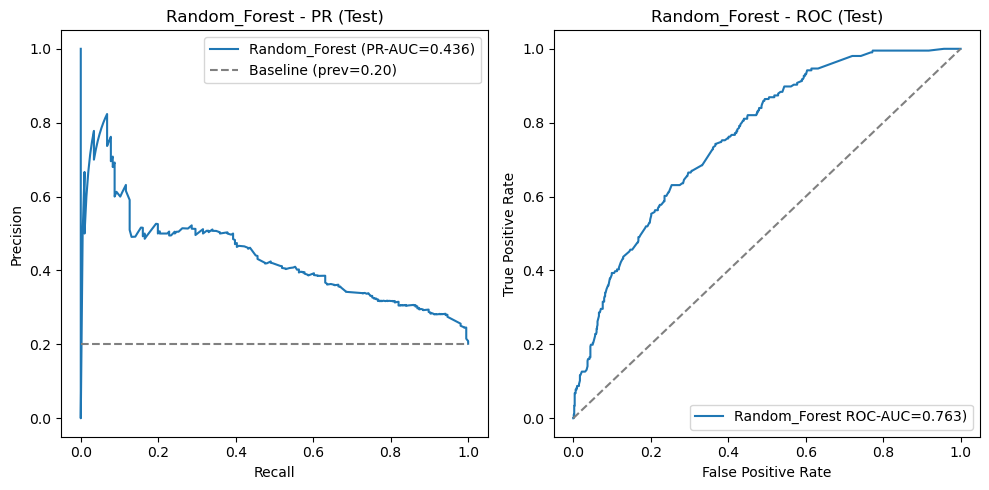

In [119]:
fig, ax = plt.subplots(1,2,figsize=(10,5))

precision, recall, pr_thresholds = precision_recall_curve(y_test, y_prob)

ax[0].plot(
    recall,
    precision,
    label=f"Random_Forest (PR-AUC={pr_test:.3f})"
)

baseline = y_test.mean()
ax[0].hlines(
    baseline, 0, 1,
    linestyles="dashed", colors="grey",
    label=f"Baseline (prev={baseline:.2f})"
)

ax[0].set_xlabel("Recall")
ax[0].set_ylabel("Precision")
ax[0].set_title("Random_Forest - PR (Test)")
ax[0].legend()

# --------------------
# ROC
# --------------------

fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)

ax[1].plot(
    fpr,
    tpr,
    label=f"Random_Forest ROC-AUC={roc_test:.3f})"
)

ax[1].plot([0, 1], [0, 1], '--', color='grey')
ax[1].set_xlabel("False Positive Rate")
ax[1].set_ylabel("True Positive Rate")
ax[1].set_title("Random_Forest - ROC (Test)")
ax[1].legend()

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/model/optimization/random_forest_pr_roc_curves.png")
plt.show()


## LightGBM

In [120]:
# Option A: single validation split (fast)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=42
)


In [121]:
best_roc = 0
best_pr = 0

def objective(trial):
    global best_roc, best_pr
    params = {
        "objective": "binary",
        "metric": "auc",  # used for pruning
        "class_pos_weight": imbalance_ratio,
        "boosting_type": "gbdt",
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 16, 256),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 200),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "lambda_l1": trial.suggest_float("lambda_l1", 1e-8, 10.0, log=True),
        "lambda_l2": trial.suggest_float("lambda_l2", 1e-8, 10.0, log=True),
        "verbosity": -1,
        "seed": 99,
    }

    # Training
    
    dtrain = lgb.Dataset(X_train, label=y_train)
    dvalid = lgb.Dataset(X_val, label=y_val)

    pruning_callback = optuna.integration.LightGBMPruningCallback(
        trial, metric="auc"
    )
    model = lgb.train(
        params,
        dtrain,
        num_boost_round=1000,
        valid_sets=[dvalid],
        callbacks=[
            pruning_callback,
            lgb.early_stopping(50, verbose=False),
        ]
    )

    y_pred_cv = model.predict(X_val, num_iteration=model.best_iteration)

    roc = roc_auc_score(y_val, y_pred_cv)
    pr  = average_precision_score(y_val, y_pred_cv)

    # Store metrics
    trial.set_user_attr("roc_auc", roc)
    trial.set_user_attr("pr_auc", pr)

    # Only print if new PR-AUC is higher than previous best
    if pr > best_pr:
        best_roc = roc
        best_pr  = pr
        print(f"New best trial {trial.number}: ROC={roc:.4f}, PR={pr:.4f}")

    return roc


In [122]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

study_lgb = optuna.create_study(
    direction="maximize",
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10)
)

study_lgb.optimize(objective, n_trials=100)


New best trial 0: ROC=0.7116, PR=0.3612
New best trial 1: ROC=0.7142, PR=0.3740
New best trial 11: ROC=0.7147, PR=0.3747
New best trial 13: ROC=0.7200, PR=0.3762
New best trial 22: ROC=0.7225, PR=0.3870
New best trial 23: ROC=0.7395, PR=0.4035
New best trial 38: ROC=0.7271, PR=0.4049


In [123]:
# fit best hyperparameter conf
best_params = study_lgb.best_trial.params
best_params.update({
    "objective": "binary",
    "metric": "auc",
    "verbosity": -1,
})

final_lgb = lgb.LGBMClassifier(
    **best_params,
    n_estimators=1000
)

final_lgb.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="auc",
    callbacks=[lgb.early_stopping(50, verbose=False)],
)


LGBMClassifier(colsample_bytree=0.5715855054732266,
               lambda_l1=0.2676511721977255, lambda_l2=0.31899668078944027,
               learning_rate=0.04627294385146559, max_depth=8, metric='auc',
               min_child_samples=43, n_estimators=1000, num_leaves=51,
               objective='binary', subsample=0.539749754734164, verbosity=-1)

### Predict optimized model on test set

In [124]:
y_pred = final_lgb.predict_proba(X_test)[:, 1]

roc_test = roc_auc_score(y_test, y_pred)
pr_test  = average_precision_score(y_test, y_pred)

summary = f"""
LIGHTGBM
Best trial (validation):
  ROC-AUC: {study_lgb.best_trial.user_attrs['roc_auc']:.4f}
  PR-AUC:  {study_lgb.best_trial.user_attrs['pr_auc']:.4f}

Test set:
  ROC-AUC: {roc_test:.4f}
  PR-AUC:  {pr_test:.4f}
"""

print(summary)



LIGHTGBM
Best trial (validation):
  ROC-AUC: 0.7416
  PR-AUC:  0.3797

Test set:
  ROC-AUC: 0.7404
  PR-AUC:  0.4197



### Plot

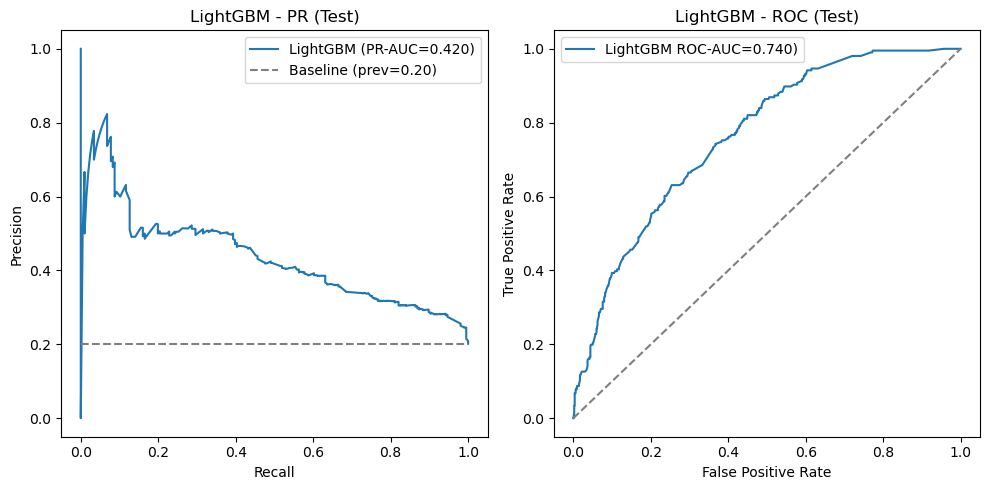

In [125]:
fig, ax = plt.subplots(1,2,figsize=(10,5))

precision, recall, pr_thresholds = precision_recall_curve(y_test, y_prob)

ax[0].plot(
    recall,
    precision,
    label=f"LightGBM (PR-AUC={pr_test:.3f})"
)

baseline = y_test.mean()
ax[0].hlines(
    baseline, 0, 1,
    linestyles="dashed", colors="grey",
    label=f"Baseline (prev={baseline:.2f})"
)

ax[0].set_xlabel("Recall")
ax[0].set_ylabel("Precision")
ax[0].set_title("LightGBM - PR (Test)")
ax[0].legend()

# --------------------
# ROC
# --------------------

fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)

ax[1].plot(
    fpr,
    tpr,
    label=f"LightGBM ROC-AUC={roc_test:.3f})"
)

ax[1].plot([0, 1], [0, 1], '--', color='grey')
ax[1].set_xlabel("False Positive Rate")
ax[1].set_ylabel("True Positive Rate")
ax[1].set_title("LightGBM - ROC (Test)")
ax[1].legend()

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/model/optimization/lightgbm_pr_roc_curves.png")
plt.show()


## XGBoost - optuna

In [126]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=42
)

In [127]:
best_pr = 0
best_roc = 0

def objective(trial):
    global best_pr, best_roc
    # Suggest hyperparameters
    params = {
        "objective": "binary:logistic",
        "eval_metric": "auc",  # used for pruning
        "class_pos_weight": imbalance_ratio,
        "tree_method": "hist",  # fast
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "min_child_weight": trial.suggest_float("min_child_weight", 1e-3, 10.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "random_state": 99,
    }


    # Training
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dvalid = xgb.DMatrix(X_val, label=y_val)

    pruning_callback = optuna.integration.XGBoostPruningCallback(
        trial, "validation_0-auc"
    )

    evals_result = {}
    model = xgb.train(
        params,
        dtrain,
        num_boost_round=1000,
        evals=[(dvalid, "validation_0")],
        early_stopping_rounds=50,
        verbose_eval=False,
        callbacks=[pruning_callback],
        evals_result=evals_result
    )

    # Predictions
    y_pred_cv = model.predict(dvalid, iteration_range=(0, model.best_iteration))

    # Metrics
    roc = roc_auc_score(y_val, y_pred_cv)
    pr = average_precision_score(y_val, y_pred_cv)

    # Store metrics
    trial.set_user_attr("roc_auc", roc)
    trial.set_user_attr("pr_auc", pr)

    # Only print if new PR-AUC is higher than previous best
    if pr > best_pr:
        best_roc = roc
        best_pr  = pr
        print(f"New best trial {trial.number}: ROC={roc:.4f}, PR={pr:.4f}")

    # Return ROC-AUC for Optuna to maximize (pruning callback watches this)
    return roc


### Run optimization

In [128]:
# run optuna
study_xgb = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner(n_warmup_steps=10))
study_xgb.optimize(objective, n_trials=100)

New best trial 0: ROC=0.7031, PR=0.3799
New best trial 2: ROC=0.7156, PR=0.3874
New best trial 20: ROC=0.7065, PR=0.3910
New best trial 58: ROC=0.7235, PR=0.4006
New best trial 63: ROC=0.7363, PR=0.4354


In [129]:
# fit best hypermparametrization

best_params = study_xgb.best_trial.params
best_params.update({"objective": "binary:logistic", "eval_metric": "auc", "tree_method": "hist"})

final_xgb = xgb.XGBClassifier(
    **best_params,
    n_estimators=1000  # let early stopping during .fit() handle iterations
)
final_xgb.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.5945756906412396, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='auc', feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03589251435136151,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=2.9397010463735076, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=None, num_parallel_tree=None, ...)

### Predict optimized model on test set

In [130]:
y_pred = final_xgb.predict_proba(X_test)[:, 1]

roc_test = roc_auc_score(y_test, y_pred)
pr_test  = average_precision_score(y_test, y_pred)

summary = f"""
XGBOOST
Best trial (validation):
  ROC-AUC: {study_xgb.best_trial.user_attrs['roc_auc']:.4f}
  PR-AUC:  {study_xgb.best_trial.user_attrs['pr_auc']:.4f}

Test set:
  ROC-AUC: {roc_test:.4f}
  PR-AUC:  {pr_test:.4f}
"""

print(summary)



XGBOOST
Best trial (validation):
  ROC-AUC: 0.7380
  PR-AUC:  0.3986

Test set:
  ROC-AUC: 0.7409
  PR-AUC:  0.4379



### Plot

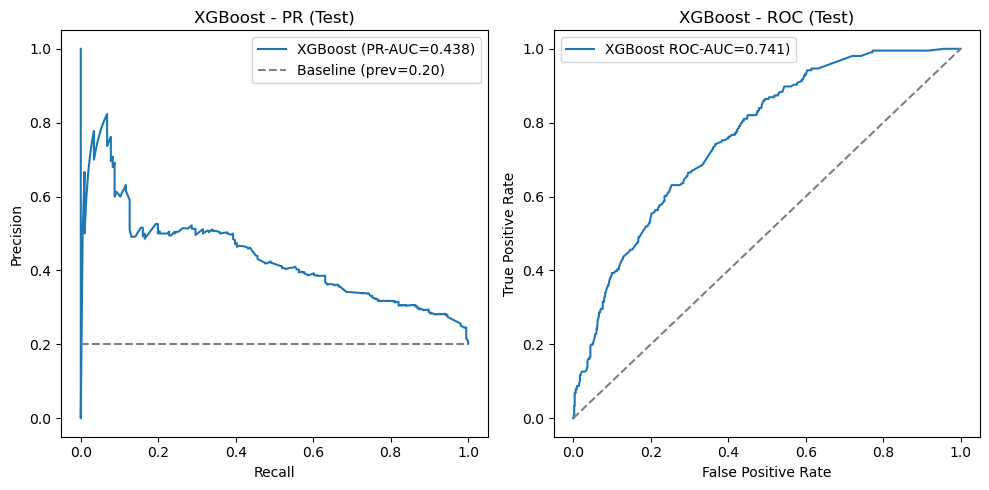

In [131]:
fig, ax = plt.subplots(1,2,figsize=(10,5))

precision, recall, pr_thresholds = precision_recall_curve(y_test, y_prob)

ax[0].plot(
    recall,
    precision,
    label=f"XGBoost (PR-AUC={pr_test:.3f})"
)

baseline = y_test.mean()
ax[0].hlines(
    baseline, 0, 1,
    linestyles="dashed", colors="grey",
    label=f"Baseline (prev={baseline:.2f})"
)

ax[0].set_xlabel("Recall")
ax[0].set_ylabel("Precision")
ax[0].set_title("XGBoost - PR (Test)")
ax[0].legend()

# --------------------
# ROC
# --------------------

fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)

ax[1].plot(
    fpr,
    tpr,
    label=f"XGBoost ROC-AUC={roc_test:.3f})"
)

ax[1].plot([0, 1], [0, 1], '--', color='grey')
ax[1].set_xlabel("False Positive Rate")
ax[1].set_ylabel("True Positive Rate")
ax[1].set_title("XGBoost - ROC (Test)")
ax[1].legend()

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/model/optimization/xgboost_pr_roc_curves.png")
plt.show()


## CatBoost

In [11]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=42
)

In [12]:
best_pr = 0
best_roc = 0

def objective(trial):
    global best_pr, best_roc
    
    params_ctb = {
        "iterations": 3000,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "depth": trial.suggest_int("depth", 4, 6),  # 🔴 constrain depth
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 5.0, 80.0, log=True),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 50, 300),
        "random_strength": trial.suggest_float("random_strength", 0.0, 1.0),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.3, 2.0),
        "bootstrap_type": "Bayesian",
        "loss_function": "Logloss",
        "eval_metric": "PRAUC",
        "class_weights": [
            1.0,
            trial.suggest_float("pos_weight", imbalance_ratio * 0.5, imbalance_ratio * 1.5)
        ],
        "random_seed": 99,
        "verbose": False,
        "allow_writing_files": False,
    }

    model = CatBoostClassifier(**params_ctb)

    model.fit(
        X_train,
        y_train,
        eval_set=(X_val, y_val),
        early_stopping_rounds=100,
        use_best_model=True,
        verbose=False
    )

    y_pred = model.predict_proba(X_val)[:, 1]

    pr_auc  = average_precision_score(y_val, y_pred)
    roc_auc = roc_auc_score(y_val, y_pred)

    # Store both metrics
    trial.set_user_attr("roc_auc", roc_auc)
    trial.set_user_attr("pr_auc", pr_auc)

    # Only print if new PR-AUC is higher than previous best
    if pr_auc > best_pr:
        best_roc = roc_auc
        best_pr  = pr_auc
        print(f"New best trial {trial.number}: ROC={roc_auc:.4f}, PR={pr_auc:.4f}")
    return pr_auc  # 🔴 OPTIMIZE WHAT YOU CARE ABOUT


In [13]:
# run optuna
study_ctb= optuna.create_study(direction="maximize", pruner=None)
# study_xgb = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner(n_warmup_steps=10))
study_ctb.optimize(objective, n_trials=100)

New best trial 0: ROC=0.7269, PR=0.4145
New best trial 20: ROC=0.7309, PR=0.4195
New best trial 24: ROC=0.7270, PR=0.4203
New best trial 28: ROC=0.7248, PR=0.4367
New best trial 42: ROC=0.7289, PR=0.4400
New best trial 74: ROC=0.7311, PR=0.4418


In [14]:
# fit best hypermparametrization
best_params_ctb = study_ctb.best_trial.params

# Map tuned parameters to CatBoost
catboost_params = {
    "learning_rate": best_params_ctb["learning_rate"],
    "depth": best_params_ctb["depth"],
    "l2_leaf_reg": best_params_ctb["l2_leaf_reg"],
    "bagging_temperature": best_params_ctb["bagging_temperature"],
    "random_strength": best_params_ctb["random_strength"],
    "loss_function": "Logloss",
    "eval_metric": "PRAUC",
    "class_weights": [1, imbalance_ratio],
    "random_seed": 99,
    "verbose": False,
    "allow_writing_files":False,
    "iterations": 1000,  # max iterations, early stopping will stop sooner
}

final_ctb = CatBoostClassifier(**catboost_params)

final_ctb.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

In [15]:
# save final_ctb for testing
joblib.dump(final_ctb, "../results/model/catboost_model.pkl")
joblib.dump(X.columns.values, "../results/model/features.pkl")

['../results/model/features.pkl']

In [16]:
# save metadata
today = date.today().strftime("%Y-%m-%d")

metadata = {
    "model": "Mortality predictor",
    "version": "1.0",
    "date": today,
    "auc": best_roc,
    "prevalence": prevalence
}

with open("../results/model/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)


### Predict optimized model on test set

In [17]:
# predict test set
y_pred = final_ctb.predict_proba(X_test)[:, 1]

roc_test = roc_auc_score(y_test, y_pred)
pr_test  = average_precision_score(y_test, y_pred)

summary = f"""
CATBOOST
Best trial (validation):
  ROC-AUC: {study_ctb.best_trial.user_attrs['roc_auc']:.4f}
  PR-AUC:  {study_ctb.best_trial.user_attrs['pr_auc']:.4f}

Test set:
  ROC-AUC: {roc_test:.4f}
  PR-AUC:  {pr_test:.4f}
"""

print(summary)



CATBOOST
Best trial (validation):
  ROC-AUC: 0.7311
  PR-AUC:  0.4418

Test set:
  ROC-AUC: 0.7287
  PR-AUC:  0.3396



### Plot curves

NameError: name 'y_prob' is not defined

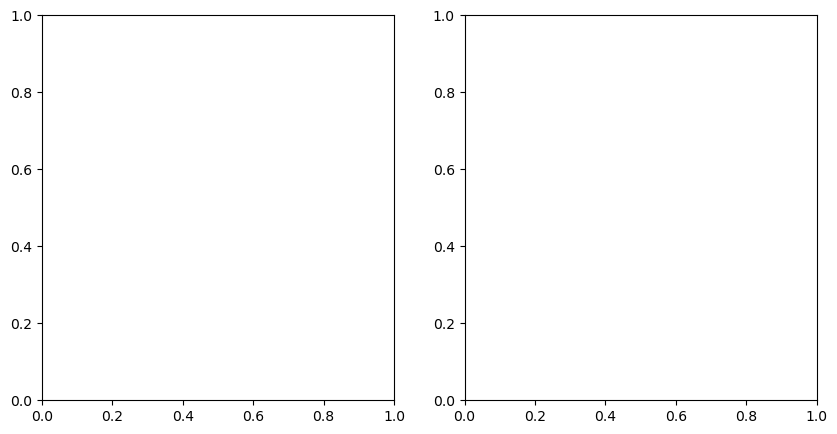

In [18]:
fig, ax = plt.subplots(1,2,figsize=(10,5))

precision, recall, pr_thresholds = precision_recall_curve(y_test, y_prob)

ax[0].plot(
    recall,
    precision,
    label=f"CatBoost (PR-AUC={pr_test:.3f})"
)

ax[0].hlines(
    baseline, 0, 1,
    linestyles="dashed", colors="grey",
    label=f"Baseline (prev={prevalence:.2f})"
)

ax[0].set_xlabel("Recall")
ax[0].set_ylabel("Precision")
ax[0].set_title("CatBoost - PR (Test)")
ax[0].legend()

# --------------------
# ROC
# --------------------

fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)

ax[1].plot(
    fpr,
    tpr,
    label=f"CatBoost ROC-AUC={roc_test:.3f})"
)

ax[1].plot([0, 1], [0, 1], '--', color='grey')
ax[1].set_xlabel("False Positive Rate")
ax[1].set_ylabel("True Positive Rate")
ax[1].set_title("CatBoost - ROC (Test)")
ax[1].legend()

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/model/optimization/catboost_pr_roc_curves.png")
plt.show()
